# Influence of conditioning
One run over several condition numbers `conds`, one matrix each. Plot 1: error against the iteration for one chosen `cond`, with the predicted $K_D$. Plot 2: the number of iterations to reach `eps` against the condition number $\kappa$, for all `conds`. Each iterate is frozen once its error reaches `eps`. Change `conds` or `sigma_max` (or `dtype`) and rerun.

In [11]:
import sys
sys.path.insert(0, "..")  # repo root, so ns_core and experiments import

import matplotlib.pyplot as plt
import torch

from ns_core import orbit_tools, plots
from experiments.conditioning import ConditioningConfig, run_conditioning
%matplotlib inline

In [14]:
cfg = ConditioningConfig(
    m=64, n=64, rank=None, conds=[2, 5, 1e1, 1e2, 1e3, 1e4, 1e5, 1e6, 1e7, 1e8], sigma_max=1.0, spectrum="log", degrees=[1, 2, 3, 4],
    k_max=50,    # steps run at most
    eps=1e-8,     # accuracy for the step counts and the freeze (also sets the predicted K_D); None = 10 machine eps,
                  # which is usually below the error floor (about u * cond), so nothing is reached
    dtype=torch.float64, device="cpu", seed=0,
)

res = run_conditioning(cfg)

D=1: 6 iterations  (predicted K_D = 7)
D=2: 4 iterations  (predicted K_D = 4)
D=3: 3 iterations  (predicted K_D = 4)
D=4: 3 iterations  (predicted K_D = 3)


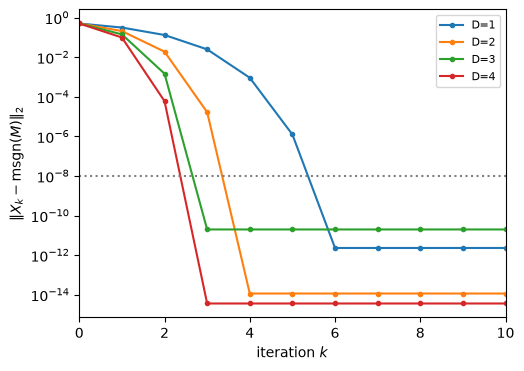

In [15]:
cond_show = 2   # plot 1: one of cfg.conds

orbit_tools.report_iterations(res["iterations"][cond_show], res["predicted"][cond_show])
plots.plot_error_curves(
    res["error"][cond_show], eps=res["eps"], predicted=res["predicted"][cond_show],
    show_predicted=False,   # dashed vertical lines at predicted K_D
    show_first_hit=False,   # mark the first step with error <= eps
    show_eps_line=True,    # horizontal line at eps
    k_plot=10,           # last step shown (None = all)
);

## Plot 2: iterations to reach `eps` against $\kappa$
All `conds` of the run above, one curve per D, against the predicted $K_D$. An open marker means `eps` was not reached within `k_max`.

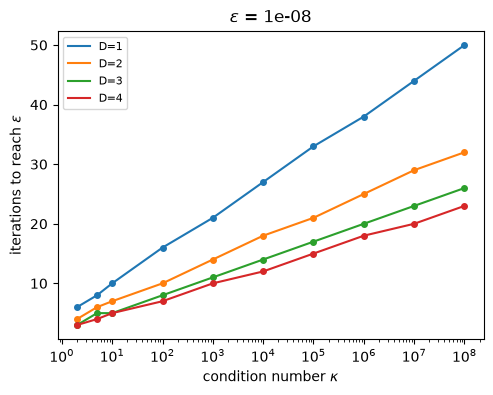

In [16]:
import os

ax = plots.plot_iterations_vs_cond(
    res,
    show_predicted=False,   # dashed lines at predicted K_D
    show_first_hit=True,   # observed first step with error <= eps
)
os.makedirs("../figures", exist_ok=True)
ax.figure.savefig(f"../figures/conditioning_iterations_vs_cond_m{cfg.m}_n{cfg.n}.pdf", bbox_inches="tight")